In [2]:
!pip install tensorflow torch -q


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import numpy as np
import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim

np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

In [3]:
# Input data
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

# Output data
y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=np.float32)

print("Input X:")
print(X)

print("\nOutput y:")
print(y)

Input X:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Output y:
[[0.]
 [1.]
 [1.]
 [0.]]


In [5]:
from tensorflow import keras
from tensorflow.keras import layers

In [6]:
keras_model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(4, activation='tanh'),
    layers.Dense(1, activation='sigmoid')
])

keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = keras_model.fit(
    X,
    y,
    epochs=1000,
    verbose=0
)

print("Keras model training completed.")

Keras model training completed.


In [9]:
loss, accuracy = keras_model.evaluate(X, y, verbose=0)

print("Keras Loss:", loss)
print("Keras Accuracy:", accuracy)

Keras Loss: 0.005508561618626118
Keras Accuracy: 1.0


In [10]:
keras_predictions = keras_model.predict(X, verbose=0)

keras_classes = (keras_predictions >= 0.5).astype(int)

print("Input:")
print(X)

print("\nPredicted probabilities:")
print(keras_predictions)

print("\nPredicted classes:")
print(keras_classes)

print("\nActual:")
print(y.astype(int))

Input:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Predicted probabilities:
[[3.302437e-04]
 [9.928541e-01]
 [9.953112e-01]
 [9.784388e-03]]

Predicted classes:
[[0]
 [1]
 [1]
 [0]]

Actual:
[[0]
 [1]
 [1]
 [0]]


In [11]:
X_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.float32)

print("X:")
print(X_torch)

print("\ny:")
print(y_torch)

X:
tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])

y:
tensor([[0.],
        [1.],
        [1.],
        [0.]])


In [12]:
class XORNet(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(2, 4),
            nn.Tanh(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x)


torch_model = XORNet()

print(torch_model)

XORNet(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): Tanh()
    (2): Linear(in_features=4, out_features=1, bias=True)
    (3): Sigmoid()
  )
)


In [13]:
criterion = nn.BCELoss()

optimizer = optim.Adam(
    torch_model.parameters(),
    lr=0.01
)

In [14]:
epochs = 1000

for epoch in range(epochs):
    
    # Forward pass
    output = torch_model(X_torch)
    
    # Calculate loss
    loss = criterion(output, y_torch)
    
    # Clear previous gradients
    optimizer.zero_grad()
    
    # Backpropagation
    loss.backward()
    
    # Update weights
    optimizer.step()

print("PyTorch model training completed.")

PyTorch model training completed.


In [15]:
with torch.no_grad():
    
    torch_predictions = torch_model(X_torch)
    
    torch_classes = (torch_predictions >= 0.5).float()

accuracy = (torch_classes == y_torch).float().mean()

print("PyTorch Loss:", loss.item())
print("PyTorch Accuracy:", accuracy.item())

PyTorch Loss: 0.0031821238808333874
PyTorch Accuracy: 1.0


In [16]:
print("Input:")
print(X_torch)

print("\nPredicted probabilities:")
print(torch_predictions)

print("\nPredicted classes:")
print(torch_classes)

print("\nActual:")
print(y_torch)

Input:
tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])

Predicted probabilities:
tensor([[0.0038],
        [0.9969],
        [0.9970],
        [0.0027]])

Predicted classes:
tensor([[0.],
        [1.],
        [1.],
        [0.]])

Actual:
tensor([[0.],
        [1.],
        [1.],
        [0.]])


In [17]:
X_tf = tf.constant(X, dtype=tf.float32)
y_tf = tf.constant(y, dtype=tf.float32)

print("X:")
print(X_tf)

print("\ny:")
print(y_tf)

X:
tf.Tensor(
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]], shape=(4, 2), dtype=float32)

y:
tf.Tensor(
[[0.]
 [1.]
 [1.]
 [0.]], shape=(4, 1), dtype=float32)


In [18]:
# Input layer - Hidden layer
W1 = tf.Variable(
    tf.random.normal([2, 4])
)

b1 = tf.Variable(
    tf.zeros([4])
)

# Hidden layer - Output layer
W2 = tf.Variable(
    tf.random.normal([4, 1])
)

b2 = tf.Variable(
    tf.zeros([1])
)

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (2, 4)
b1 shape: (4,)
W2 shape: (4, 1)
b2 shape: (1,)


In [19]:
def forward(X):
    
    # Hidden layer
    hidden = tf.tanh(
        tf.matmul(X, W1) + b1
    )
    
    # Output layer
    output = tf.sigmoid(
        tf.matmul(hidden, W2) + b2
    )
    
    return output

In [20]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.01
)

In [21]:
epochs = 1000

for epoch in range(epochs):
    
    with tf.GradientTape() as tape:
        
        # Forward pass
        predictions = forward(X_tf)
        
        # Calculate Binary Cross-Entropy
        loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(
                y_tf,
                predictions
            )
        )
    
    # Calculate gradients
    gradients = tape.gradient(
        loss,
        [W1, b1, W2, b2]
    )
    
    # Update weights
    optimizer.apply_gradients(
        zip(
            gradients,
            [W1, b1, W2, b2]
        )
    )

print("TensorFlow low-level model training completed.")

TensorFlow low-level model training completed.


In [22]:
tf_predictions = forward(X_tf)

tf_classes = tf.cast(
    tf_predictions >= 0.5,
    tf.float32
)

tf_accuracy = tf.reduce_mean(
    tf.cast(tf_classes == y_tf, tf.float32)
)

print("TensorFlow Loss:", loss.numpy())
print("TensorFlow Accuracy:", tf_accuracy.numpy())

TensorFlow Loss: 0.0076934295
TensorFlow Accuracy: 1.0


In [23]:
print("Input:")
print(X)

print("\nPredicted probabilities:")
print(tf_predictions.numpy())

print("\nPredicted classes:")
print(tf_classes.numpy())

print("\nActual:")
print(y.astype(int))

Input:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Predicted probabilities:
[[6.9369259e-04]
 [9.8568022e-01]
 [9.9740118e-01]
 [1.2918958e-02]]

Predicted classes:
[[0.]
 [1.]
 [1.]
 [0.]]

Actual:
[[0]
 [1]
 [1]
 [0]]


In [24]:
print("XOR Prediction Comparison")
print("=" * 50)

print("\nInput     Actual    Keras    PyTorch    TensorFlow")

for i in range(4):
    
    print(
        X[i],
        "     ",
        int(y[i][0]),
        "       ",
        int(keras_classes[i][0]),
        "        ",
        int(torch_classes[i][0]),
        "          ",
        int(tf_classes[i][0])
    )

XOR Prediction Comparison

Input     Actual    Keras    PyTorch    TensorFlow
[0. 0.]       0         0          0            0
[0. 1.]       1         1          1            1
[1. 0.]       1         1          1            1
[1. 1.]       0         0          0            0


In [25]:
def train_xor(neurons=4, activation='tanh', learning_rate=0.01, epochs=1000):
    
    model = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(neurons, activation=activation),
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    model.fit(
        X,
        y,
        epochs=epochs,
        verbose=0
    )
    
    loss, accuracy = model.evaluate(
        X,
        y,
        verbose=0
    )
    
    return loss, accuracy

In [26]:
for neurons in [2, 4, 8]:
    
    loss, accuracy = train_xor(
        neurons=neurons,
        activation='tanh',
        learning_rate=0.01,
        epochs=1000
    )
    
    print(
        "Neurons:", neurons,
        "| Loss:", round(loss, 4),
        "| Accuracy:", round(accuracy, 4)
    )

Neurons: 2 | Loss: 0.0093 | Accuracy: 1.0
Neurons: 4 | Loss: 0.3486 | Accuracy: 0.5
Neurons: 8 | Loss: 0.0006 | Accuracy: 1.0


In [27]:
for lr in [0.001, 0.01, 0.1]:
    
    loss, accuracy = train_xor(
        neurons=4,
        activation='tanh',
        learning_rate=lr,
        epochs=1000
    )
    
    print(
        "Learning Rate:", lr,
        "| Loss:", round(loss, 4),
        "| Accuracy:", round(accuracy, 4)
    )

Learning Rate: 0.001 | Loss: 0.2293 | Accuracy: 1.0
Learning Rate: 0.01 | Loss: 0.0053 | Accuracy: 1.0
Learning Rate: 0.1 | Loss: 0.0001 | Accuracy: 1.0


In [28]:
for epochs in [100, 500, 1000]:
    
    loss, accuracy = train_xor(
        neurons=4,
        activation='tanh',
        learning_rate=0.01,
        epochs=epochs
    )
    
    print(
        "Epochs:", epochs,
        "| Loss:", round(loss, 4),
        "| Accuracy:", round(accuracy, 4)
    )

Epochs: 100 | Loss: 0.3902 | Accuracy: 1.0
Epochs: 500 | Loss: 0.0082 | Accuracy: 1.0
Epochs: 1000 | Loss: 0.0036 | Accuracy: 1.0


In [29]:
print("Final XOR Results")
print("=" * 40)

print("Input 1 | Input 2 | Expected | Predicted")
print("-" * 40)

for i in range(4):
    
    print(
        f"   {int(X[i][0])}    |    "
        f"{int(X[i][1])}    |    "
        f"{int(y[i][0])}      |    "
        f"{int(keras_classes[i][0])}"
    )

Final XOR Results
Input 1 | Input 2 | Expected | Predicted
----------------------------------------
   0    |    0    |    0      |    0
   0    |    1    |    1      |    1
   1    |    0    |    1      |    1
   1    |    1    |    0      |    0


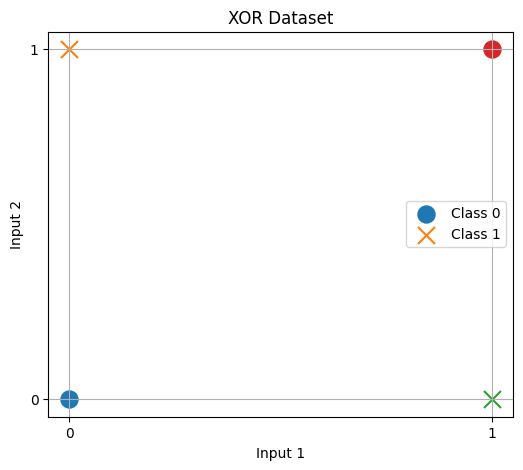

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

for i in range(len(X)):
    if y[i][0] == 0:
        plt.scatter(X[i][0], X[i][1], s=150, marker='o', label='Class 0' if i == 0 else "")
    else:
        plt.scatter(X[i][0], X[i][1], s=150, marker='x', label='Class 1' if i == 1 else "")

plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("XOR Dataset")
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.legend()
plt.grid(True)
plt.show()

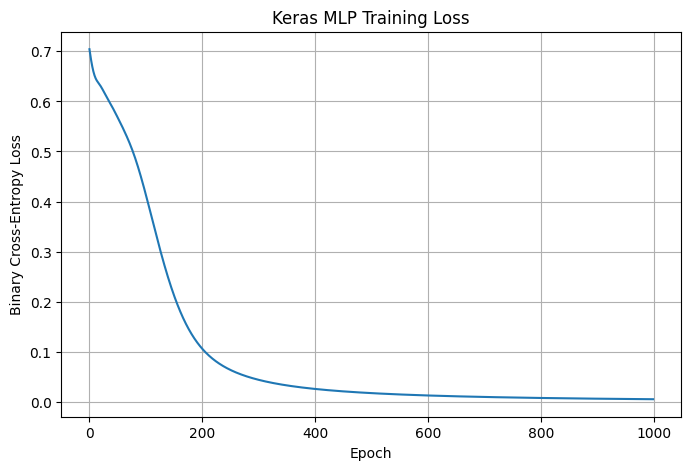

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'])

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Keras MLP Training Loss")
plt.grid(True)

plt.show()